# 04 - Error Analysis
**Credit Score Classification | MLOps Group 8**

This notebook performs a deep analysis of model errors on the test set:
- Overall error rate and per-class breakdown
- Misclassification patterns (which classes confuse the model)
- Feature analysis of misclassified samples
- Low-confidence prediction analysis
- Error clustering (are errors systematic or random?)
- Business impact of errors (False Negatives on 'Good', False Positives on 'Poor')

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

REPO_ROOT   = Path().resolve().parent
DATA_PROC   = REPO_ROOT / 'data' / 'processed'
MODELS_DIR  = REPO_ROOT / 'artifacts' / 'models'
REPORTS_DIR = REPO_ROOT / 'artifacts' / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(REPO_ROOT))

CLASS_NAMES  = ['Poor', 'Standard', 'Good']
LABEL_MAP    = {'Poor': 0, 'Standard': 1, 'Good': 2}
LABEL_MAP_INV= {0: 'Poor', 1: 'Standard', 2: 'Good'}
COLOR_MAP    = {'Poor': '#d9534f', 'Standard': '#f0ad4e', 'Good': '#5cb85c'}

print('Repo root:', REPO_ROOT)

Repo root: D:\code\Python\DSEB_ex\MLOps-Group-8


## 1. Load Test Data and Model Predictions

In [2]:
bundle_path = MODELS_DIR / 'final_model_bundle.pkl'
data_path   = DATA_PROC / 'test_split.csv'

if not bundle_path.exists():
    raise FileNotFoundError('Run training_pipeline first to generate the model bundle.')
if not data_path.exists():
    raise FileNotFoundError('Run training_pipeline first to generate the processed test set.')

from src.models.serialize import load_bundle

bundle   = load_bundle(bundle_path)
df_test  = pd.read_csv(data_path)
print(f'Test set shape: {df_test.shape}')
print(f'Model version: {bundle.metadata.get("model_version", "unknown")}')

[serialize] Bundle loaded <- D:\code\Python\DSEB_ex\MLOps-Group-8\artifacts\models\final_model_bundle.pkl
Test set shape: (15000, 28)
Model version: 1.0.0


In [3]:
# Transform and predict
X_test = bundle.transform(df_test)
y_true_raw = df_test['Credit_Score'].map(LABEL_MAP)

valid_mask = y_true_raw.notna()
X_test   = X_test[valid_mask]
y_true   = y_true_raw[valid_mask].astype(int).values
df_test_valid = df_test[valid_mask].reset_index(drop=True)

y_pred   = bundle.model.predict(X_test)
y_proba  = bundle.model.predict_proba(X_test)

y_true_names = [LABEL_MAP_INV[v] for v in y_true]
y_pred_names = [LABEL_MAP_INV[v] for v in y_pred]

print(f'Predictions generated for {len(y_true)} samples.')

[preprocessing] Dropped PII: ['ID', 'Customer_ID', 'Name', 'SSN', 'Month'] — remaining cols: 23
[ImputerPipeline] WARN - Remaining NaN after imputation:
Type_of_Loan    1693
[build_features] Added 10 derived features.
  New columns: ['debt_to_income', 'loan_to_income', 'emi_to_income', 'savings_rate', 'balance_to_income', 'credit_card_util_proxy', 'delay_per_loan', 'delinquency_rate', 'inquiry_per_account', 'credit_age_years']
  Output shape: (15000, 51)
Predictions generated for 15000 samples.


## 2. Overall Error Rate

In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc      = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
n_errors = (y_true != y_pred).sum()

print(f'Test set size:    {len(y_true):,}')
print(f'Errors:           {n_errors:,} ({n_errors/len(y_true)*100:.1f}%)')
print(f'Accuracy:         {acc:.4f}')
print(f'Macro F1:         {f1_macro:.4f}')
print(f'Weighted F1:      {f1_weighted:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test set size:    15,000
Errors:           4,088 (27.3%)
Accuracy:         0.7275
Macro F1:         0.7052
Weighted F1:      0.7268

=== Classification Report ===
              precision    recall  f1-score   support

        Poor       0.73      0.72      0.72      4350
    Standard       0.75      0.77      0.76      7976
        Good       0.65      0.62      0.63      2674

    accuracy                           0.73     15000
   macro avg       0.71      0.70      0.71     15000
weighted avg       0.73      0.73      0.73     15000



## 3. Confusion Matrix

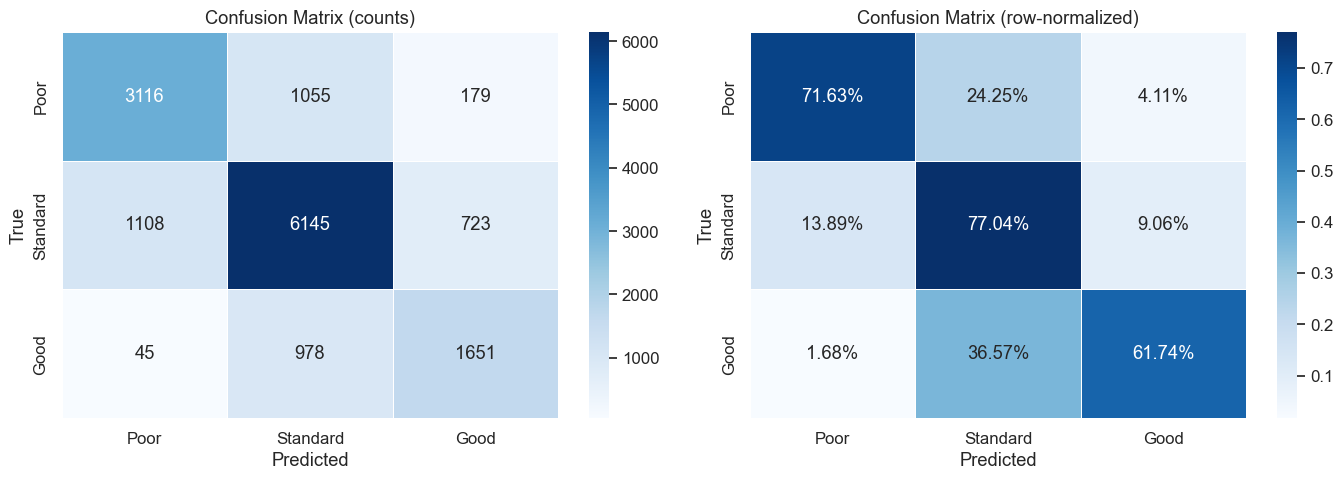

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (counts)')

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (row-normalized)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_analysis_confusion_matrix.png', dpi=150)
plt.show()

## 4. Misclassification Pattern Analysis

In [6]:
results_df = pd.DataFrame({
    'true_label':  y_true_names,
    'pred_label':  y_pred_names,
    'correct':     [t == p for t, p in zip(y_true_names, y_pred_names)],
    'confidence':  y_proba.max(axis=1),
    'prob_Poor':    y_proba[:, 0],
    'prob_Standard':y_proba[:, 1],
    'prob_Good':    y_proba[:, 2],
})

# Error breakdown
errors_df = results_df[~results_df['correct']].copy()
errors_df['error_type'] = errors_df['true_label'] + ' -> ' + errors_df['pred_label']

error_type_counts = errors_df['error_type'].value_counts()
print(f'Total errors: {len(errors_df):,}')
print()
print('Most common misclassification patterns:')
print(error_type_counts.to_string())

Total errors: 4,088

Most common misclassification patterns:
error_type
Standard -> Poor    1108
Poor -> Standard    1055
Good -> Standard     978
Standard -> Good     723
Poor -> Good         179
Good -> Poor          45


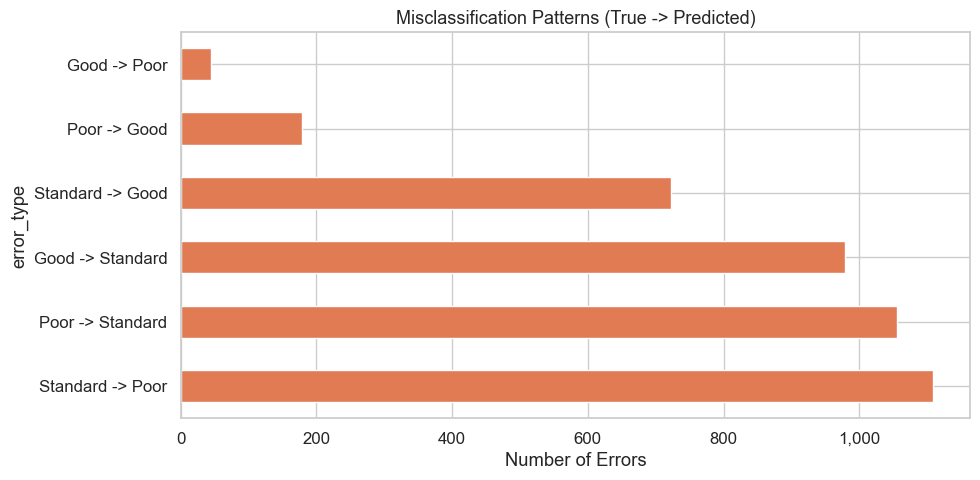

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
error_type_counts.plot(kind='barh', ax=ax, color='#e07b54')
ax.set_title('Misclassification Patterns (True -> Predicted)', fontsize=13)
ax.set_xlabel('Number of Errors')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_patterns.png', dpi=150)
plt.show()

## 5. Confidence Distribution: Correct vs. Incorrect

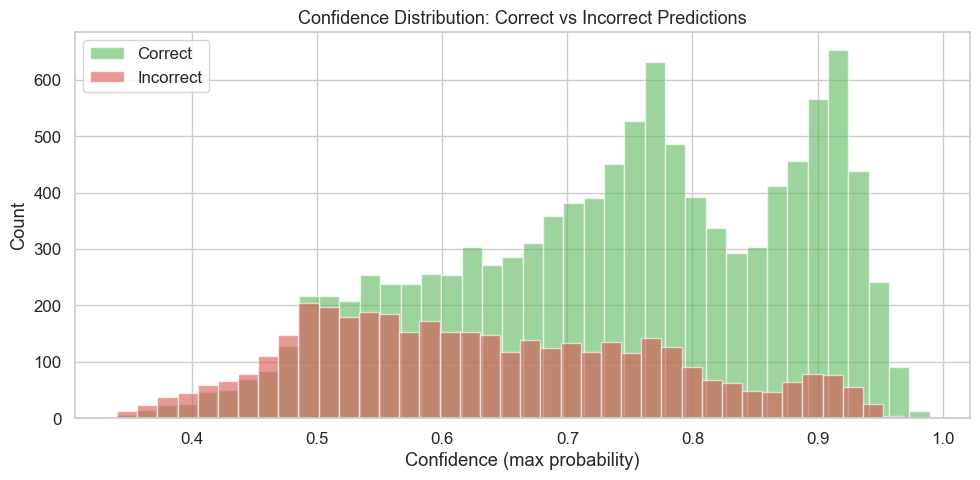

Median confidence -- Correct: 0.758
Median confidence -- Incorrect: 0.617


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df[results_df['correct']]['confidence'].hist(
    bins=40, ax=ax, alpha=0.6, label='Correct', color='#5cb85c'
)
results_df[~results_df['correct']]['confidence'].hist(
    bins=40, ax=ax, alpha=0.6, label='Incorrect', color='#d9534f'
)
ax.set_xlabel('Confidence (max probability)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution: Correct vs Incorrect Predictions', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confidence_distribution.png', dpi=150)
plt.show()

print(f'Median confidence -- Correct: {results_df[results_df["correct"]]["confidence"].median():.3f}')
print(f'Median confidence -- Incorrect: {results_df[~results_df["correct"]]["confidence"].median():.3f}')

## 6. Feature Analysis of Misclassified Samples

In [9]:
# # Key numeric features from original test data
# key_features = [
#     'Age', 'Annual_Income', 'Outstanding_Debt',
#     'Delay_from_due_date', 'Num_of_Delayed_Payment',
#     'Credit_Utilization_Ratio', 'Credit_History_Age'
# ]
# key_features = [f for f in key_features if f in df_test_valid.columns]

# analysis_df = df_test_valid[key_features].copy()
# analysis_df['correct'] = results_df['correct'].values
# analysis_df['true_label'] = results_df['true_label'].values
# analysis_df['pred_label'] = results_df['pred_label'].values
# analysis_df['confidence'] = results_df['confidence'].values

# print('Feature comparison: correct vs incorrect predictions')
# for feat in key_features:
#     correct_mean   = analysis_df[analysis_df['correct']][feat].mean()
#     incorrect_mean = analysis_df[~analysis_df['correct']][feat].mean()
#     diff_pct = (incorrect_mean - correct_mean) / (abs(correct_mean) + 1e-9) * 100
#     print(f'  {feat:30s}: correct={correct_mean:8.2f}, incorrect={incorrect_mean:8.2f}, diff={diff_pct:+.1f}%')

In [10]:
# # Box plots: key features for each error type
# top_errors = error_type_counts.head(4).index.tolist()

# if len(top_errors) > 0 and len(key_features) >= 4:
#     analysis_df['error_type'] = np.where(
#         analysis_df['correct'], 'Correct',
#         analysis_df['true_label'] + ' -> ' + analysis_df['pred_label']
#     )
#     plot_feats = key_features[:4]
#     fig, axes = plt.subplots(1, 4, figsize=(20, 6))

#     for ax, feat in zip(axes, plot_feats):
#         data = analysis_df[analysis_df['error_type'].isin(['Correct'] + top_errors)]
#         sns.boxplot(
#             data=data, x='error_type', y=feat,
#             showfliers=False, ax=ax
#         )
#         ax.set_title(feat, fontsize=10)
#         ax.set_xlabel('')
#         ax.set_xticklabels(ax.get_xticklabels(), rotation=30, fontsize=8)

#     plt.suptitle('Feature Distributions by Prediction Outcome', fontsize=13, y=1.01)
#     plt.tight_layout()
#     plt.savefig(FIGURES_DIR / 'error_feature_comparison.png', dpi=150, bbox_inches='tight')
#     plt.show()

## 7. Low-Confidence Prediction Analysis

In [11]:
CONFIDENCE_THRESHOLD = 0.60

low_conf = results_df[results_df['confidence'] < CONFIDENCE_THRESHOLD]
print(f'Low-confidence predictions (< {CONFIDENCE_THRESHOLD}): {len(low_conf):,} '
      f'({len(low_conf)/len(results_df)*100:.1f}%)')
print(f'Error rate among low-confidence: {(~low_conf["correct"]).mean()*100:.1f}%')
print(f'Error rate among high-confidence: '
      f'{(~results_df[results_df["confidence"]>=CONFIDENCE_THRESHOLD]["correct"]).mean()*100:.1f}%')

Low-confidence predictions (< 0.6): 3,968 (26.5%)
Error rate among low-confidence: 47.5%
Error rate among high-confidence: 20.0%


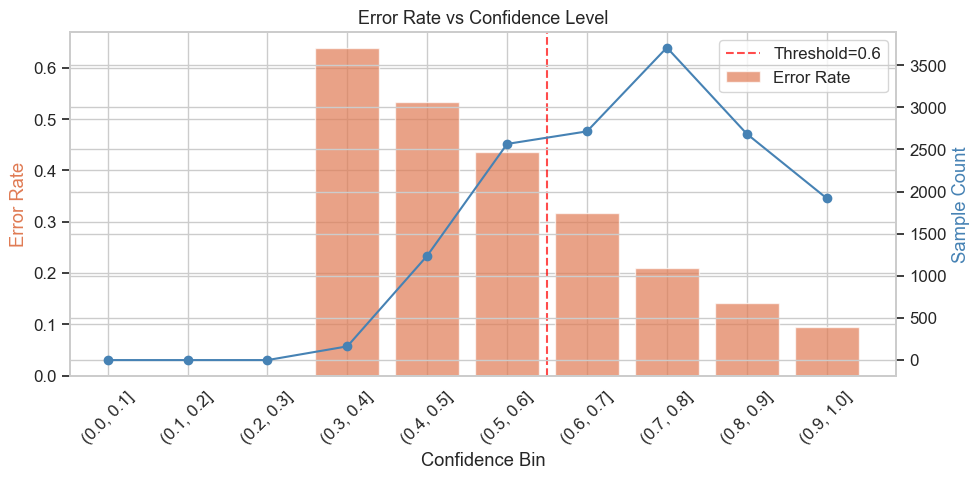

In [12]:
# Error rate by confidence bin
bins = np.arange(0, 1.05, 0.1)
results_df['conf_bin'] = pd.cut(results_df['confidence'], bins=bins)
error_rate_by_conf = results_df.groupby('conf_bin')['correct'].agg(['mean', 'count'])
error_rate_by_conf['error_rate'] = 1 - error_rate_by_conf['mean']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x_labels = [str(b) for b in error_rate_by_conf.index]
x = range(len(x_labels))

ax1.bar(x, error_rate_by_conf['error_rate'], color='#e07b54', alpha=0.7, label='Error Rate')
ax2.plot(x, error_rate_by_conf['count'], 'o-', color='steelblue', label='Sample Count')

ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)
ax1.set_xlabel('Confidence Bin')
ax1.set_ylabel('Error Rate', color='#e07b54')
ax2.set_ylabel('Sample Count', color='steelblue')
ax1.set_title('Error Rate vs Confidence Level', fontsize=13)
ax1.axvline(CONFIDENCE_THRESHOLD * 10 - 0.5, color='red', ls='--',
            alpha=0.7, label=f'Threshold={CONFIDENCE_THRESHOLD}')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_rate_by_confidence.png', dpi=150)
plt.show()

## 8. Business Impact Analysis

In [13]:
# Critical business errors:
# Type A: True Poor -> Predicted Good (approve risky customer - HIGH IMPACT)
# Type B: True Good -> Predicted Poor (reject safe customer - MEDIUM IMPACT)
# Type C: True Standard -> either extreme (border cases)

type_a = ((np.array(y_true_names) == 'Poor') & (np.array(y_pred_names) == 'Good')).sum()
type_b = ((np.array(y_true_names) == 'Good') & (np.array(y_pred_names) == 'Poor')).sum()
type_c = ((np.array(y_true_names) == 'Standard') & (np.array(y_pred_names) != 'Standard')).sum()

total_poor  = (np.array(y_true_names) == 'Poor').sum()
total_good  = (np.array(y_true_names) == 'Good').sum()
total_std   = (np.array(y_true_names) == 'Standard').sum()

print('=== BUSINESS IMPACT ANALYSIS ===')
print()
print(f'Type A (Poor -> Good, approve risky):  {type_a:5,} / {total_poor:,} '
      f'Poor customers ({type_a/total_poor*100:.1f}%)  [HIGH RISK]')
print(f'Type B (Good -> Poor, reject safe):    {type_b:5,} / {total_good:,} '
      f'Good customers ({type_b/total_good*100:.1f}%)  [REVENUE LOSS]')
print(f'Type C (Standard misclassified):       {type_c:5,} / {total_std:,} '
      f'Standard customers ({type_c/total_std*100:.1f}%)')
print()
print('Recommendation:')
print('  - Type A errors are the most costly. Raise confidence threshold or add manual review.')
print('  - Type B errors represent lost revenue. Monitor closely and calibrate model.')
print(f'  - Current threshold (0.60) routes {len(low_conf)/len(results_df)*100:.1f}% to manual review.')

=== BUSINESS IMPACT ANALYSIS ===

Type A (Poor -> Good, approve risky):    179 / 4,350 Poor customers (4.1%)  [HIGH RISK]
Type B (Good -> Poor, reject safe):       45 / 2,674 Good customers (1.7%)  [REVENUE LOSS]
Type C (Standard misclassified):       1,831 / 7,976 Standard customers (23.0%)

Recommendation:
  - Type A errors are the most costly. Raise confidence threshold or add manual review.
  - Type B errors represent lost revenue. Monitor closely and calibrate model.
  - Current threshold (0.60) routes 26.5% to manual review.


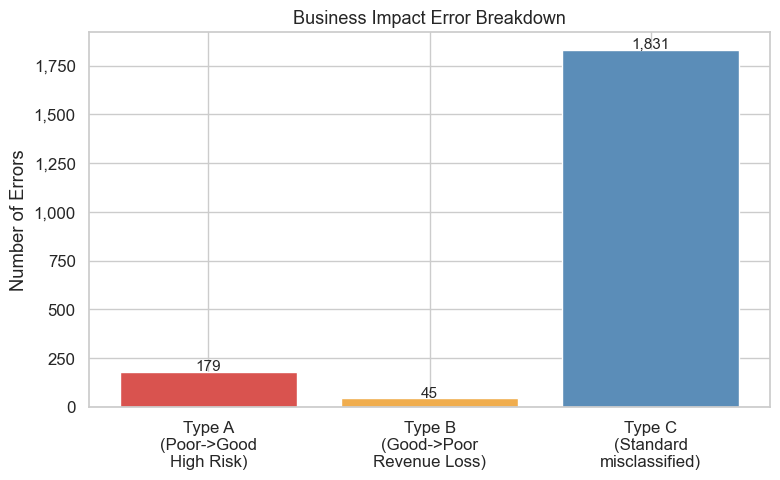

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = [
    'Type A\n(Poor->Good\nHigh Risk)',
    'Type B\n(Good->Poor\nRevenue Loss)',
    'Type C\n(Standard\nmisclassified)'
]
counts = [type_a, type_b, type_c]
colors = ['#d9534f', '#f0ad4e', '#5b8db8']
bars = ax.bar(categories, counts, color=colors, edgecolor='white')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{cnt:,}', ha='center', fontsize=11)
ax.set_ylabel('Number of Errors')
ax.set_title('Business Impact Error Breakdown', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'business_impact_errors.png', dpi=150)
plt.show()

## 9. Error Analysis Summary

In [15]:
print('=== ERROR ANALYSIS SUMMARY ===')
print(f'Total test samples:         {len(y_true):,}')
print(f'Total errors:               {n_errors:,} ({n_errors/len(y_true)*100:.1f}%)')
print(f'Most common error:          {error_type_counts.index[0]} ({error_type_counts.iloc[0]:,} cases)')
print(f'Low-confidence predictions: {len(low_conf):,} ({len(low_conf)/len(results_df)*100:.1f}%)')
print(f'Error rate in low-conf:     {(~low_conf["correct"]).mean()*100:.1f}%')
print(f'Critical Type A errors:     {type_a:,} ({type_a/total_poor*100:.1f}% of Poor class)')
print()
print('Recommendations:')
print('  1. Investigate Standard<->Poor boundary -- highest confusion area')
print('  2. Consider raising confidence threshold to reduce high-risk Type A errors')
print('  3. Collect more training data for minority class (Good) if possible')
print('  4. Add PSI monitoring for Delay_from_due_date and Outstanding_Debt')
print('     as these are key discriminators in error cases')

=== ERROR ANALYSIS SUMMARY ===
Total test samples:         15,000
Total errors:               4,088 (27.3%)
Most common error:          Standard -> Poor (1,108 cases)
Low-confidence predictions: 3,968 (26.5%)
Error rate in low-conf:     47.5%
Critical Type A errors:     179 (4.1% of Poor class)

Recommendations:
  1. Investigate Standard<->Poor boundary -- highest confusion area
  2. Consider raising confidence threshold to reduce high-risk Type A errors
  3. Collect more training data for minority class (Good) if possible
  4. Add PSI monitoring for Delay_from_due_date and Outstanding_Debt
     as these are key discriminators in error cases
